# Deepseek : Patnaik Pearson dimension of token embeddings
## For e.g. N = 2000, sample N tokens randonly (without replacement) from the full vocabulary
## Calculate the PP dim of the resulting data manifold X (of dimension N * d)
## Here d = 1536
## Do this for some number of samples, plot histogram of the PP dims
## See how PP dim changes as N increases. What is the maximum N that's feasible?

In [1]:
import torch
from transformers import AutoTokenizer, AutoModel

C:\Users\Dell\OneDrive\Documents\TomDocuments\PythonProjects\PP\20260527\PatnaikPearson\ml_env311_v2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from scipy.linalg import qr

import math
import pandas as pd
import random

In [3]:
import PatnaikPearson as pp
import cupy

In [4]:
# Config
N = 2000
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_NAME = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"

In [5]:
# Load model & tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
).to(DEVICE)
model.eval()

Qwen2Model(
  (embed_tokens): Embedding(151936, 1536)
  (layers): ModuleList(
    (0-27): 28 x Qwen2DecoderLayer(
      (self_attn): Qwen2SdpaAttention(
        (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
        (k_proj): Linear(in_features=1536, out_features=256, bias=True)
        (v_proj): Linear(in_features=1536, out_features=256, bias=True)
        (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        (rotary_emb): Qwen2RotaryEmbedding()
      )
      (mlp): Qwen2MLP(
        (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
        (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
        (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
        (act_fn): SiLU()
      )
      (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
    )
  )
  (norm): Qwen2RMSNorm((1536,), eps=1e-06)
)

In [6]:
N = 250
num_iterations = 10
verbose = True

xx = pp.DeepSeek_R1_Distill_Qwen_1_5B_token_embedding_initial_pp_dim_experiment(model, 
                                                     tokenizer,
                                                     DEVICE,
                                                     N, 
                                                     num_iterations,
                                                     verbose
                                                    )

vocab_size =  151643
iteration 0
0 212.8208770751953 0.13855525851249695
iteration 1
1 214.2776641845703 0.13950368762016296
iteration 2
2 218.6825714111328 0.14237146576245627
iteration 3
3 210.04673767089844 0.13674917817115784
iteration 4
4 212.792724609375 0.13853693008422852
iteration 5
5 211.5675506591797 0.13773929079373678
iteration 6
6 215.38136291503906 0.14022224148114523
iteration 7
7 216.84767150878906 0.1411768694718679
iteration 8
8 216.04421997070312 0.1406537890434265
iteration 9
9 214.10472106933594 0.13939109444618225


In [8]:
# read from csv:
file_name = 'pp_deepseek_r1_distill_qwen_1_5B_embedding_pp_dim_nu_over_d.csv'
df = pd.read_csv(file_name)
print(df.shape)
print(df.head(5))
print(df.tail(5))

(180, 3)
    value_type    N      values
0  pp_dim_vals  500  410.546509
1  pp_dim_vals  500  403.752472
2  pp_dim_vals  500  402.937500
3  pp_dim_vals  500  401.995636
4  pp_dim_vals  500  408.026123
         value_type      N    values
175  nu_over_d_vals  20000  0.921400
176  nu_over_d_vals  20000  0.921183
177  nu_over_d_vals  20000  0.921511
178  nu_over_d_vals  20000  0.921055
179  nu_over_d_vals  20000  0.921181


In [9]:
# plot graphs for nu/d
this_key = 'nu_over_d_vals'
df2 = df.loc[df['value_type'] == this_key]
print(df2.shape)

N_vals = df2['N'].unique()
print(N_vals)
print(type(N_vals))

nu_over_d_mean_vals = np.zeros(len(N_vals))
nu_over_d_std_vals = np.zeros(len(N_vals))

i = 0
for N in N_vals:
    df2_N = df2[df2['N'] == N]
    print(N,df2_N.shape, type(df2_N))
    this_mean = df2_N['values'].mean()
    this_std = df2_N['values'].std()
    print(N, this_mean, this_std)
    nu_over_d_mean_vals[i] = this_mean
    nu_over_d_std_vals[i] = this_std
    i+=1

(90, 3)
[  500  1000  1536  2000  3000  5000  7500 10000 20000]
<class 'numpy.ndarray'>
500 (10, 3) <class 'pandas.DataFrame'>
500 0.2627658049265543 0.0030786271156080934
1000 (10, 3) <class 'pandas.DataFrame'>
1000 0.47634377479553225 0.004198077102391624
1536 (10, 3) <class 'pandas.DataFrame'>
1536 0.6411198854446412 0.0013673040174404043
2000 (10, 3) <class 'pandas.DataFrame'>
2000 0.7199010133743285 0.0020635634357826526
3000 (10, 3) <class 'pandas.DataFrame'>
3000 0.7968860546747843 0.0014135099635210378
5000 (10, 3) <class 'pandas.DataFrame'>
5000 0.856285325686137 0.0006027672161003478
7500 (10, 3) <class 'pandas.DataFrame'>
7500 0.884977650642395 0.0007010252142006599
10000 (10, 3) <class 'pandas.DataFrame'>
10000 0.8997510592142742 0.00030961168331962744
20000 (10, 3) <class 'pandas.DataFrame'>
20000 0.9212058067321778 0.00022021667698620157


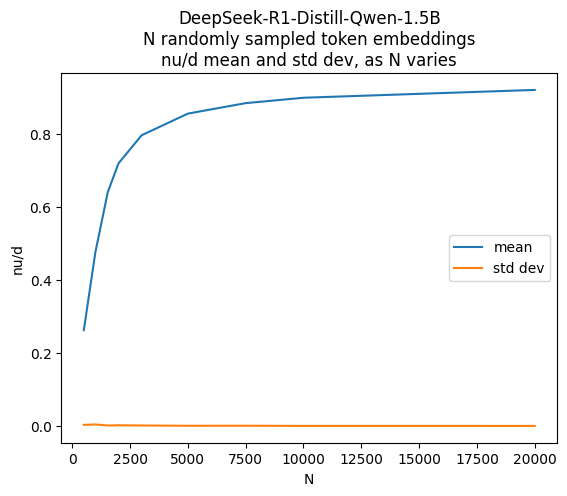

In [10]:
this_title = "DeepSeek-R1-Distill-Qwen-1.5B\n"
this_title += "N randomly sampled token embeddings\n"
this_title += "nu/d mean and std dev, as N varies"
plt.plot(N_vals, nu_over_d_mean_vals, label = "mean")
plt.plot(N_vals, nu_over_d_std_vals, label = "std dev")
plt.xlabel("N")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
#plt.savefig('deepseek_token_embedding_nu_over_d.pdf', dpi=300, bbox_inches='tight')
plt.show()

# ** OLD AND SPARE **

In [ ]:
# Sample 2000 token IDs without replacement
vocab_size = tokenizer.vocab_size
print("vocab_size = ", vocab_size)
perm = torch.randperm(vocab_size)[:N]  # random permutation, take first N
sampled_token_ids = perm.to(DEVICE)
print(f"Sampled {N} token IDs without replacement")
print("First 10 tokens:", tokenizer.convert_ids_to_tokens(sampled_token_ids[:10].tolist()))

In [ ]:
# Extract embeddings directly from the embedding layer
# No need for a forward pass — just index into the embedding matrix directly
embedding_layer = model.embed_tokens  # (vocab_size, hidden_size)

In [ ]:
print(type(embedding_layer))

In [ ]:
with torch.no_grad():
    token_embeddings = embedding_layer(sampled_token_ids)  # (N, hidden_size)

In [ ]:
print(f"\nEmbedding matrix shape: {token_embeddings.shape}")  # (2000, 1536)
print(f"dtype: {token_embeddings.dtype}")
print(f"device: {token_embeddings.device}")

In [ ]:
#numpy_array = tensor_cpu.numpy()
X = (token_embeddings.cpu()).numpy()
print(type(X))
print(X.shape)

In [ ]:
N = 7500
num_iterations = 10
verbose = True

xx = DeepSeek_R1_Distill_Qwen_1_5B_token_embedding_initial_pp_dim_experiment(model, 
                                                     tokenizer,
                                                     DEVICE,
                                                     N, 
                                                     num_iterations,
                                                     verbose
                                                    )

In [ ]:
#xx_2000 = xx
#xx_5000 = xx
#xx_10000 = xx
##xx_20000 = xx
#xx_1536 = xx
#xx_1000 = xx
#xx_500 = xx
#xx_3000 = xx
##xx_7500 = xx

In [ ]:
# create an empty dataframe
df = pd.DataFrame({
'value_type': [],
'N': [],
'values': []
})

these_xx = { 500 : xx_500, 
1000 : xx_1000, 
1536 : xx_1536, 
2000 : xx_2000, 
3000 : xx_3000, 
5000 : xx_5000, 
7500 : xx_7500,
10000 : xx_10000, 
20000 : xx_20000
}

for N in these_xx:
    #print(N)
    xx = these_xx[N]
    #print(type(xx))
    for key_xx in xx:
        #print(N, key_xx)
        xx_vals = xx[key_xx]
        for this_val in xx_vals:
            #print(key_xx, N, this_val)
            df.loc[len(df)] = [key_xx, N, this_val]

In [ ]:
print(df.head(5))
print(df.tail(5))

In [ ]:
# export to csv
file_name = 'pp_deepseek_r1_distill_qwen_1_5B_embedding_pp_dim_nu_over_d.csv'
df.to_csv(file_name, index=False)

In [ ]:
this_key = 'nu_over_d_vals'
df2 = df.loc[df['value_type'] == this_key]
print(df2.shape)

In [ ]:
this_key = 'nu_over_d_vals'
df2 = df.loc[df['value_type'] == this_key]
print(df2.shape)

N_vals = df2['N'].unique()
print(N_vals)
print(type(N_vals))

nu_over_d_mean_vals = np.zeros(len(N_vals))
nu_over_d_std_vals = np.zeros(len(N_vals))

i = 0
for N in N_vals:
    df2_N = df2[df2['N'] == N]
    print(N,df2_N.shape, type(df2_N))
    this_mean = df2_N['values'].mean()
    this_std = df2_N['values'].std()
    print(N, this_mean, this_std)
    nu_over_d_mean_vals[i] = this_mean
    nu_over_d_std_vals[i] = this_std
    i+=1

In [ ]:
this_title = "DeepSeek-R1-Distill-Qwen-1.5B\n"
this_title += "N randomly sampled token embeddings\n"
this_title += "nu/d mean and std dev, as N varies"
plt.plot(N_vals, nu_over_d_mean_vals, label = "mean")
plt.plot(N_vals, nu_over_d_std_vals, label = "std dev")
plt.xlabel("N")
plt.ylabel("nu/d")
plt.legend()
plt.title(this_title)
plt.savefig('deepseek_token_embedding_nu_over_d.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def DeepSeek_R1_Distill_Qwen_1_5B_token_embedding_initial_pp_dim_experiment(model : 'transformers.models.qwen2.modeling_qwen2.Qwen2Model', 
                                                     tokenizer : 'transformers.models.llama.tokenization_llama_fast.LlamaTokenizerFast',
                                                     DEVICE : 'torch.device',
                                                     N : int = 2000, 
                                                     num_iterations : int = 1,
                                                     verbose : bool = False
                                                    ):

    pp_dim_vals = np.zeros(num_iterations)
    nu_over_d_vals = np.zeros(num_iterations)

    max_N = 130000 # max context length (approx)
    N = min(N, max_N)

    vocab_size = tokenizer.vocab_size
    print("vocab_size = ", vocab_size)

    # Extract embeddings directly from the embedding layer
    # No need for a forward pass — just index into the embedding matrix directly
    embedding_layer = model.embed_tokens  # (vocab_size, hidden_size)
    
    for i in range(num_iterations):
        print("iteration " + str(i))
        #random_token_ids = torch.randperm(vocab_size, dtype=torch.long)[:N]
        perm = torch.randperm(vocab_size)[:N]  # random permutation, take first N
        sampled_token_ids = perm.to(DEVICE)
        
        # Extract embeddings directly from the embedding layer
        # No need for a forward pass — just index into the embedding matrix directly
        with torch.no_grad():
            token_embeddings = embedding_layer(sampled_token_ids)  # (N, hidden_size)

        # convert to numpy array
        X = ((token_embeddings.cpu()).numpy()).astype(np.float32)
        # np_rep = (rep.cpu().numpy()).astype(np.float32)
        pp_dim_X = float(pp.calculate_PatnaikPearson_dim(X))
        dim_X = X.shape[1]
        nu_over_d_X = pp_dim_X / dim_X
        if verbose:
            print(i, pp_dim_X, nu_over_d_X)

        pp_dim_vals[i] = pp_dim_X
        nu_over_d_vals[i] = nu_over_d_X

    results_dict = {
        "pp_dim_vals" : pp_dim_vals,
        "nu_over_d_vals" : nu_over_d_vals
    }

    return results_dict
        
        

    